In [350]:
import pandas as pd
import numpy as np

In [351]:
data = pd.read_csv("train.csv")
data

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1d1af,CUS_0x3539,February,an Arakalid,30,995-31-4669,Manager,43391.96,3688.996667,1,...,Good,1468.28,29.112468,23 Years and 8 Months,No,0.000000,53.969385063055675,High_spent_Large_value_payments,554.9302816036111,Good
1,0x1ebd6,CUS_0x8716,January,Matthewz,18,185-99-8068,Scientist,14351.21,NaN,8,...,Bad,4766.87,39.849732,NaN,Yes,61.098718,118.08021357217683,Low_spent_Small_value_payments,238.3144849566528,Poor
2,0x8a66,CUS_0x21dc,January,Tom Miless,41,241-53-8475,Developer,130125.04,10871.753333,5,...,Good,1195.05,21.542892,15 Years and 11 Months,No,204.285650,1255.8993022448951,Low_spent_Small_value_payments,NaN,Good
3,0x1d769,CUS_0x32d3,April,Lisaa,35,204-78-6176,Manager,20107.21,1631.600833,6,...,Standard,2544.6,32.423759,19 Years and 4 Months,Yes,27.106395,66.81977464950728,Low_spent_Small_value_payments,359.23391378882377,Poor
4,0x236dd,CUS_0xadad,August,Masond,27,027-11-6852,Doctor,92186.19,7487.182500,1,...,Good,809.01,39.543131,20 Years and 9 Months,No,185.797654,115.52003931707223,High_spent_Medium_value_payments,697.4005568630175,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,0x3af4,CUS_0x74d5,March,NaN,25,432-94-4099,Lawyer,13826843.0,NaN,5,...,_,1485.97,37.016730,26 Years and 11 Months,No,21.189697,35.9996408171615,High_spent_Large_value_payments,383.82566221916846,Poor
79996,0x1461b,CUS_0xbf40,June,Ryan Vlastelicam,27,#F%$D@*&8,Doctor,81864.56,6882.046667,8,...,Standard,1210.87,38.790160,20 Years and 4 Months,Yes,74.807701,177.96767573986224,High_spent_Small_value_payments,695.4292896635706,Standard
79997,0x3952,CUS_0x5300,May,Schnurri,20,857-13-4456,Musician,7985.155,870.429583,6,...,Bad,1954.62,37.819647,13 Years and 0 Months,Yes,46.177189,102.77595238390127,!@9#%8,228.0898169891847,Poor
79998,0x16cd1,CUS_0x6a84,April,imarte Walterx,45,670-40-8222,_______,69279.38,5836.281667,3,...,Good,1475.0,26.144018,20 Years and 2 Months,No,0.000000,466.17158115399417,Low_spent_Large_value_payments,387.45658551267263,Poor


Data Manipulation

In [352]:
# reset ID
data['ID'] = data.index+1

In [353]:
# check Null
check_null = pd.DataFrame(columns=['num_null', 'percent_null'])
check_null['num_null'] = data.isnull().sum()
check_null['percent_null'] = round(check_null['num_null'] / len(data) *100,2)
check_null

,num_null,percent_null
ID,0,0.00
Customer_ID,0,0.00
Month,0,0.00
Name,8008,10.01
Age,0,0.00
SSN,0,0.00
Occupation,0,0.00
Annual_Income,0,0.00
Monthly_Inhand_Salary,11962,14.95
Num_Bank_Accounts,0,0.00


In [354]:
print(f"Original shape of data: {data.shape}")
print(f"New shape of data after dropping nulls: {data.dropna(inplace=False).shape}")

Original shape of data: (80000, 28)
New shape of data after dropping nulls: (42391, 28)


In [355]:
data

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,CUS_0x3539,February,an Arakalid,30,995-31-4669,Manager,43391.96,3688.996667,1,...,Good,1468.28,29.112468,23 Years and 8 Months,No,0.000000,53.969385063055675,High_spent_Large_value_payments,554.9302816036111,Good
1,2,CUS_0x8716,January,Matthewz,18,185-99-8068,Scientist,14351.21,NaN,8,...,Bad,4766.87,39.849732,NaN,Yes,61.098718,118.08021357217683,Low_spent_Small_value_payments,238.3144849566528,Poor
2,3,CUS_0x21dc,January,Tom Miless,41,241-53-8475,Developer,130125.04,10871.753333,5,...,Good,1195.05,21.542892,15 Years and 11 Months,No,204.285650,1255.8993022448951,Low_spent_Small_value_payments,NaN,Good
3,4,CUS_0x32d3,April,Lisaa,35,204-78-6176,Manager,20107.21,1631.600833,6,...,Standard,2544.6,32.423759,19 Years and 4 Months,Yes,27.106395,66.81977464950728,Low_spent_Small_value_payments,359.23391378882377,Poor
4,5,CUS_0xadad,August,Masond,27,027-11-6852,Doctor,92186.19,7487.182500,1,...,Good,809.01,39.543131,20 Years and 9 Months,No,185.797654,115.52003931707223,High_spent_Medium_value_payments,697.4005568630175,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,79996,CUS_0x74d5,March,NaN,25,432-94-4099,Lawyer,13826843.0,NaN,5,...,_,1485.97,37.016730,26 Years and 11 Months,No,21.189697,35.9996408171615,High_spent_Large_value_payments,383.82566221916846,Poor
79996,79997,CUS_0xbf40,June,Ryan Vlastelicam,27,#F%$D@*&8,Doctor,81864.56,6882.046667,8,...,Standard,1210.87,38.790160,20 Years and 4 Months,Yes,74.807701,177.96767573986224,High_spent_Small_value_payments,695.4292896635706,Standard
79997,79998,CUS_0x5300,May,Schnurri,20,857-13-4456,Musician,7985.155,870.429583,6,...,Bad,1954.62,37.819647,13 Years and 0 Months,Yes,46.177189,102.77595238390127,!@9#%8,228.0898169891847,Poor
79998,79999,CUS_0x6a84,April,imarte Walterx,45,670-40-8222,_______,69279.38,5836.281667,3,...,Good,1475.0,26.144018,20 Years and 2 Months,No,0.000000,466.17158115399417,Low_spent_Large_value_payments,387.45658551267263,Poor


Dealing with null

In [356]:
update_data = data.copy()

In [357]:
# check Null
check_null = pd.DataFrame(columns=['num_null', 'percent_null'])
check_null['num_null'] = update_data.isnull().sum()
check_null['percent_null'] = round(check_null['num_null'] / len(update_data) *100,2)
check_null

,num_null,percent_null
ID,0,0.00
Customer_ID,0,0.00
Month,0,0.00
Name,8008,10.01
Age,0,0.00
SSN,0,0.00
Occupation,0,0.00
Annual_Income,0,0.00
Monthly_Inhand_Salary,11962,14.95
Num_Bank_Accounts,0,0.00


Name

In [358]:
update_data['Name'] = update_data['Name'].str.replace(r'[^A-Za-z ]', '', regex=True)

In [359]:
update_data['Name'] = (update_data.groupby('Customer_ID')['Name'].transform(lambda x: x.ffill().bfill()))

print(f"Nulls in 'Name' after imputation: {update_data['Name'].isnull().sum()}")

Nulls in 'Name' after imputation: 0


In [360]:
update_data = update_data.sort_values(by=['Customer_ID', 'Name', 'Month']).reset_index(drop=True)
update_data['ID'] = update_data.index + 1
display(update_data.head())

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,CUS_0x1000,April,Alistair Barrf,17,913-74-1218,Lawyer,30625.94,2706.161667,6,...,Bad,1562.91,32.843081,10 Years and 5 Months,Yes,42.94109,87.90990881495769,!@9#%8,419.7651674292397,Poor
1,2,CUS_0x1000,February,Alistair Barrf,17,913-74-1218,Lawyer,30625.94,NaN,6,...,Bad,1562.91,29.439759,10 Years and 3 Months,Yes,42.94109,176.13256665597928,High_spent_Small_value_payments,311.542509588218,Poor
2,3,CUS_0x1000,January,Alistair Barrf,17,913-74-1218,Lawyer,30625.94,2706.161667,6,...,Bad,1562.91,26.612093,10 Years and 2 Months,Yes,42.94109,244.75028300769162,Low_spent_Large_value_payments,252.9247932365056,Standard
3,4,CUS_0x1000,July,Alistair Barrf,18,913-74-1218,Lawyer,30625.94,2706.161667,6,...,Bad,1562.91,38.149539,10 Years and 8 Months,Yes,42.94109,266.59716045509043,Low_spent_Small_value_payments,251.0779157891069,Poor
4,5,CUS_0x1000,June,Alistair Barrf,18,913-74-1218,Lawyer,30625.94,2706.161667,6,...,Bad,1562.91,40.082272,10 Years and 7 Months,Yes,42.94109,114.80240059146288,High_spent_Small_value_payments,372.87267565273436,Poor


Monthly_Inhand_Salary

In [361]:
update_data['Monthly_Inhand_Salary'] = (update_data.groupby(['Customer_ID', 'Name'])['Monthly_Inhand_Salary'].transform(lambda x: x.ffill().bfill() if x.notna().any() else 'NO_INFORM'))

# Check the number of nulls in 'Monthly_Inhand_Salary' after imputation
print(f"Nulls in 'Monthly_Inhand_Salary' after imputation: {update_data['Monthly_Inhand_Salary'].isnull().sum()}")

Nulls in 'Monthly_Inhand_Salary' after imputation: 0


In [362]:
update_data['Monthly_Inhand_Salary'] = pd.to_numeric(update_data['Monthly_Inhand_Salary'], errors='coerce')

global_median = update_data['Monthly_Inhand_Salary'].median()

update_data['Monthly_Inhand_Salary'] = (
    update_data.groupby(['Customer_ID', 'Name'])['Monthly_Inhand_Salary']
    .transform(lambda x: x.fillna(x.median()) if x.notna().any() else global_median)
)

# Check the number of nulls after imputation
print(f"Nulls in 'Monthly_Inhand_Salary' after imputation: {update_data['Monthly_Inhand_Salary'].isnull().sum()}")

Nulls in 'Monthly_Inhand_Salary' after imputation: 0


Type_of_Loan

In [363]:
update_data[update_data['Type_of_Loan'].isnull()][['ID', 'Customer_ID', 'Month', 'Name', 'Type_of_Loan']].head(10)

,ID,Customer_ID,Month,Name,Type_of_Loan
13,14,CUS_0x100b,April,Shirboni,NaN
14,15,CUS_0x100b,August,Shirboni,NaN
15,16,CUS_0x100b,February,Shirboni,NaN
16,17,CUS_0x100b,July,Shirboni,NaN
17,18,CUS_0x100b,June,Shirboni,NaN
18,19,CUS_0x100b,March,Shirboni,NaN
33,34,CUS_0x1015,February,Holtono,NaN
34,35,CUS_0x1015,January,Holtono,NaN
35,36,CUS_0x1015,June,Holtono,NaN
36,37,CUS_0x1015,March,Holtono,NaN


In [364]:
update_data['Type_of_Loan'] = (update_data.groupby(['Customer_ID', 'Name'])['Type_of_Loan'].transform(lambda x: x.ffill().bfill() if x.notna().any() else 'NO_INFORM'))

# Check the number of nulls in 'Type_of_Loan' after imputation
print(f"Nulls in 'Type_of_Loan' after imputation: {update_data['Type_of_Loan'].isnull().sum()}")

Nulls in 'Type_of_Loan' after imputation: 0


In [365]:
display(update_data[update_data['Name'].isin(['Shirboni'])][['ID', 'Customer_ID', 'Month', 'Name', 'Type_of_Loan']])

,ID,Customer_ID,Month,Name,Type_of_Loan
13,14,CUS_0x100b,April,Shirboni,NO_INFORM
14,15,CUS_0x100b,August,Shirboni,NO_INFORM
15,16,CUS_0x100b,February,Shirboni,NO_INFORM
16,17,CUS_0x100b,July,Shirboni,NO_INFORM
17,18,CUS_0x100b,June,Shirboni,NO_INFORM
18,19,CUS_0x100b,March,Shirboni,NO_INFORM


Num_of_Delayed_Payment

In [366]:
update_data['Num_of_Delayed_Payment'] = pd.to_numeric(update_data['Num_of_Delayed_Payment'], errors='coerce')

global_median = update_data['Num_of_Delayed_Payment'].median()

update_data['Num_of_Delayed_Payment'] = (
    update_data.groupby(['Customer_ID', 'Name'])['Num_of_Delayed_Payment']
    .transform(lambda x: x.fillna(x.median()) if x.notna().any() else global_median)
)

# Check the number of nulls after imputation
print(f"Nulls in 'Num_of_Delayed_Payment' after imputation: {update_data['Num_of_Delayed_Payment'].isnull().sum()}")

Nulls in 'Num_of_Delayed_Payment' after imputation: 0


Num_Credit_Inquiries



In [367]:
update_data['Num_Credit_Inquiries'] = pd.to_numeric(update_data['Num_Credit_Inquiries'], errors='coerce')

global_median = update_data['Num_Credit_Inquiries'].median()

update_data['Num_Credit_Inquiries'] = (
    update_data.groupby(['Customer_ID', 'Name'])['Num_Credit_Inquiries']
    .transform(lambda x: x.fillna(x.median()) if x.notna().any() else global_median)
)

# Check the number of nulls after imputation
print(f"Nulls in 'Num_Credit_Inquiries' after imputation: {update_data['Num_Credit_Inquiries'].isnull().sum()}")

Nulls in 'Num_Credit_Inquiries' after imputation: 0


Amount_invested_monthly

In [368]:
update_data['Amount_invested_monthly'] = (update_data['Amount_invested_monthly'].astype(str).str.replace(r'[^0-9.]', '', regex=True))
update_data['Amount_invested_monthly'] = pd.to_numeric(update_data['Amount_invested_monthly'], errors='coerce')

In [369]:
global_median = update_data['Amount_invested_monthly'].median()

update_data['Amount_invested_monthly'] = (
    update_data.groupby(['Customer_ID', 'Name'])['Amount_invested_monthly']
    .transform(lambda x: x.fillna(x.median()) if x.notna().any() else global_median)
)

# Check the number of nulls after imputation
print(f"Nulls in 'Amount_invested_monthly' after imputation: {update_data['Amount_invested_monthly'].isnull().sum()}")

Nulls in 'Amount_invested_monthly' after imputation: 0


Monthly_Balance

In [370]:
update_data['Monthly_Balance'] = pd.to_numeric(update_data['Monthly_Balance'], errors='coerce')

global_median = update_data['Monthly_Balance'].median()

update_data['Monthly_Balance'] = (
    update_data.groupby(['Customer_ID', 'Name'])['Monthly_Balance']
    .transform(lambda x: x.fillna(x.median()) if x.notna().any() else global_median)
)

# Check the number of nulls after imputation
print(f"Nulls in 'Monthly_Balance' after imputation: {update_data['Monthly_Balance'].isnull().sum()}")

Nulls in 'Monthly_Balance' after imputation: 0


Credit_History_Age

In [371]:
update_data['Credit_History_Age'].unique()

array(['10 Years and 5 Months', '10 Years and 3 Months',
       '10 Years and 2 Months', '10 Years and 8 Months',
       '10 Years and 7 Months', '10 Years and 6 Months', nan,
       '31 Years and 0 Months', '30 Years and 6 Months',
       '30 Years and 11 Months', '30 Years and 10 Months',
       '30 Years and 7 Months', '30 Years and 9 Months',
       '15 Years and 6 Months', '15 Years and 10 Months',
       '15 Years and 9 Months', '15 Years and 8 Months',
       '15 Years and 5 Months', '15 Years and 4 Months',
       '15 Years and 3 Months', '17 Years and 6 Months',
       '17 Years and 10 Months', '17 Years and 3 Months',
       '17 Years and 9 Months', '17 Years and 8 Months',
       '17 Years and 5 Months', '20 Years and 10 Months',
       '21 Years and 3 Months', '21 Years and 0 Months',
       '13 Years and 11 Months', '14 Years and 3 Months',
       '13 Years and 9 Months', '13 Years and 8 Months',
       '14 Years and 2 Months', '14 Years and 0 Months',
       '20 Years and

In [372]:
temp = update_data['Credit_History_Age'].str.extract(r'(\d+)\s+Years?.*?(\d+)\s+Months?')

update_data['Credit_History_Age'] = (temp[0].astype(float)*12 + temp[1].astype(float))

In [373]:
update_data['Credit_History_Age']

0        125.0
1        123.0
2        122.0
3        128.0
4        127.0
         ...  
79995    225.0
79996    218.0
79997    224.0
79998    220.0
79999    222.0
Name: Credit_History_Age, Length: 80000, dtype: float64

In [374]:
global_median = update_data['Credit_History_Age'].median()

update_data['Credit_History_Age'] = (
    update_data.groupby(['Customer_ID', 'Name'])['Credit_History_Age']
    .transform(lambda x: x.fillna(x.median()) if x.notna().any() else global_median)
)

# Check the number of nulls after imputation
print(f"Nulls in 'Credit_History_Age' after imputation: {update_data['Credit_History_Age'].isnull().sum()}")

Nulls in 'Credit_History_Age' after imputation: 0


Check Null that was transformed into 'NO_INFORM'

In [375]:
(update_data == 'NO_INFORM').sum()

ID                             0
Customer_ID                    0
Month                          0
Name                           0
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                9213
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly        0
Payment_Behaviour              0
Monthly_Balance                0
Credit_Score                   0
dtype: int64

In [376]:
c1 = data.loc[data['Type_of_Loan'].isna(), 'Name'].drop_duplicates().tolist()
c2 = update_data.loc[update_data['Type_of_Loan']=='NO_INFORM','Name'].drop_duplicates().tolist()

diff = set(c2) - set(c1)

print(list(diff))

# code ทำงานถูก แสดงว่าที่มันเป็น Null คือข้อมูล Type of Loan ของลูกค้าคนนั้นไม่ได้ถูกเก็บข้อมูลนั้นมาตั้งแต่แรก

['Helen NyamburaMwaurar', ' Globali', 'Michaelg', 'HerbstBaylisst', 'ChangRanj', 'Sarah Nb', 'Andrea ShalalEsap', 'John ODonnellf', 'HerbstBaylissf', 'ODonnelly', 'HerbstBaylissn', 'Cr', 'John ODonnellh', 'Liana Br', 'Martin den', ' Globalt', 'ChangRan Kimi', 'Liana Bv', 'Patrick TempleWestw', 'Ag', 'Andrea ShalalEsac', 'Andrea ShalalEsal', 'ODonnello', 'Ng', 'RobertJane', 'Andrea ShalalEsax', 'Svea HerbstBaylissa', 'Sarah Nt', 'Andrea ShalalEsag', 'Nn', 'Steven Ca', 'FerreiraMarquesb', 'Ab', 'ShalalEsaf', 'Clara FerreiraMarquesn', 'Andrea ShalalEsah', 'Martiny', 'HerbstBaylisso', 'ShalalEsar', 'YSingj', 'Svea HerbstBaylisst', 'Joseph Aa', 'SaPintom', 'Nk', 'Dr', 'AlZaquanq', 'Sarah Nv', 'Steven Cr', 'OGradyg', 'Andrea ShalalEsav']


Occupation

In [377]:
update_data['Occupation'] = update_data['Occupation'].replace('_______', np.nan)

update_data['Occupation'] = (
    update_data.groupby(['Customer_ID','Name'])['Occupation']
    .transform(lambda x: x.ffill().bfill())
)

update_data['Occupation'] = update_data['Occupation'].fillna('NO_INFORM')

Credit_Mix

In [378]:
update_data['Credit_Mix'] = (
    update_data['Credit_Mix']
    .replace('_', np.nan)
    .groupby([update_data['Customer_ID'], update_data['Name']])
    .ffill()
    .bfill()
    .fillna('NO_INFORM'))

Age

In [379]:
# Remove special characters (keep only digits)
update_data['Age'] = update_data['Age'].astype(str).str.replace(r'[^0-9]', '', regex=True)

# Convert to numeric
update_data['Age'] = pd.to_numeric(update_data['Age'], errors='coerce')

# Replace Age > 100 with median of the same person
update_data['Age'] = update_data.groupby(['Customer_ID','Name'])['Age'].transform(lambda x: x.mask(x > 100, x.median()))

Num_of_Loan

In [380]:
# Remove special characters (keep only digits)
update_data['Num_of_Loan'] = update_data['Num_of_Loan'].astype(str).str.replace(r'[^0-9]', '', regex=True)

# Convert to numeric
update_data['Num_of_Loan'] = pd.to_numeric(update_data['Num_of_Loan'], errors='coerce')

update_data['Num_of_Loan'] = update_data.groupby(['Customer_ID','Name'])['Num_of_Loan'].transform(lambda x: x.mask(x < 0, x.median()))

Changed_Credit_Limit

In [381]:
# 1. Replace '_' with NaN
update_data['Changed_Credit_Limit'] = update_data['Changed_Credit_Limit'].replace('_', np.nan)

# 2. Convert to numeric
update_data['Changed_Credit_Limit'] = pd.to_numeric(update_data['Changed_Credit_Limit'], errors='coerce')

# 3. Fill NaN with median of the same person
update_data['Changed_Credit_Limit'] = (
    update_data.groupby(['Customer_ID','Name'])['Changed_Credit_Limit']
    .transform(lambda x: x.fillna(x.median())))

Outstanding_Debt

In [382]:
# 1. Replace '_' with NaN
update_data['Outstanding_Debt'] = update_data['Outstanding_Debt'].replace('_', np.nan)

# 2. Convert to numeric
update_data['Outstanding_Debt'] = pd.to_numeric(update_data['Outstanding_Debt'], errors='coerce')

# 3. Fill NaN with median of the same person
update_data['Outstanding_Debt'] = (
    update_data.groupby(['Customer_ID','Name'])['Outstanding_Debt']
    .transform(lambda x: x.fillna(x.median())))

Payment_Behaviour

In [383]:
# replace rows with special characters (except _) with NaN
update_data['Payment_Behaviour'] = update_data['Payment_Behaviour'].replace(r'[^A-Za-z_ ]', np.nan, regex=True)

# fill with closest value from the same person
update_data['Payment_Behaviour'] = (update_data.groupby(['Customer_ID','Name'])['Payment_Behaviour'].transform(lambda x: x.ffill().bfill()))

Annual_Income

In [384]:
# Remove special characters (keep only digits)
update_data['Annual_Income'] = update_data['Annual_Income'].astype(str).str.replace(r'[^0-9]', '', regex=True)

# Convert to numeric
update_data['Annual_Income'] = pd.to_numeric(update_data['Annual_Income'], errors='coerce')

update_data['Annual_Income'] = update_data.groupby(['Customer_ID','Name'])['Annual_Income'].transform(lambda x: x.mask(x < 0, x.median()))

Monthly_Inhand_Salary

In [385]:
# update_data.to_csv("update_data2.csv", index=False)

Train Model

In [386]:
update_data.dtypes

ID                            int64
Customer_ID                  object
Month                        object
Name                         object
Age                         float64
SSN                          object
Occupation                   object
Annual_Income                 int64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                   int64
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
Credit_Score                

In [387]:
update_data.tail(5)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
79995,79996,CUS_0xffd,August,Damouniq,30.0,832-88-8320,Scientist,4139844,3749.87,8,...,Standard,1701.88,39.916655,225.0,Yes,182.976649,42.575720,High_spent_Large_value_payments,389.434631,Good
79996,79997,CUS_0xffd,January,Damouniq,29.0,832-88-8320,Scientist,4139844,3749.87,8,...,Standard,1701.88,29.506673,218.0,Yes,182.976649,195.529273,Low_spent_Large_value_payments,266.481077,Standard
79997,79998,CUS_0xffd,July,Damouniq,30.0,832-88-8320,Scientist,4139844,3749.87,8,...,Standard,1701.88,33.916363,224.0,Yes,182.976649,257.989694,High_spent_Small_value_payments,194.020657,Good
79998,79999,CUS_0xffd,March,Damouniq,29.0,832-88-8320,Scientist,4139844,3749.87,8,...,Standard,1701.88,25.175964,220.0,Yes,182.976649,336.130231,Low_spent_Small_value_payments,145.880119,Standard
79999,80000,CUS_0xffd,May,Damouniq,29.0,832-88-8320,Scientist,4139844,3749.87,8,...,Standard,1701.88,26.166508,222.0,Yes,182.976649,104.629474,High_spent_Medium_value_payments,337.380877,Standard


Standardize and One hot encoder

In [388]:
# separate X and y
X = update_data.drop(['ID', 'Customer_ID','Credit_Score','SSN'], axis=1)
Y = update_data['Credit_Score']

In [389]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# numeric columns
numeric_cols = X.select_dtypes(include=['int64','float64']).columns

# categorical columns
categorical_cols = X.select_dtypes(include='object').columns

# preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# apply transformation
X_processed = preprocess.fit_transform(X)

feature_names = preprocess.get_feature_names_out()

In [390]:
X_processed

<80000x16442 sparse matrix of type '<class 'numpy.float64'>'
	with 1920000 stored elements in Compressed Sparse Row format>

Train test split

In [391]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X_processed, Y, test_size= 0.2, random_state= 42)

In [392]:
X_test

<16000x16442 sparse matrix of type '<class 'numpy.float64'>'
	with 384000 stored elements in Compressed Sparse Row format>

In [393]:
y_test

47044    Standard
44295    Standard
74783    Standard
70975    Standard
46645        Poor
           ...   
67666        Poor
51146        Poor
42494        Good
52517        Poor
7754         Good
Name: Credit_Score, Length: 16000, dtype: object

LASSO

In [394]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

model = LogisticRegression(
    penalty='l1',
    solver='saga',
    multi_class='multinomial',
    max_iter=300,
    random_state=555
)

In [395]:
selector = SelectFromModel(model)
X_new = selector.fit_transform(X_train, y_train)

c:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [396]:
X_test_new = selector.transform(X_test)

In [397]:
# train final model
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_new, y_train)

# predict
y_pred = final_model.predict(X_test_new)

In [415]:
selector.estimator_.coef_

array([[ 3.01995034e-02, -1.38239876e-02,  9.72786785e-02, ...,
        -1.91820849e-01, -2.67508515e-01, -4.07734657e-01],
       [-9.14576190e-02,  5.77238327e-03, -1.62148121e-01, ...,
         4.76005982e-02,  1.28412014e-01,  2.35260283e-01],
       [ 2.91493972e-03, -3.33326463e-08,  6.46102185e-03, ...,
         8.76628490e-02,  8.07003807e-02,  1.14059411e-01]])

In [416]:
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

f1 = f1_score(y_test, y_pred, average='macro')

print(f1)
print(classification_report(y_test, y_pred))

0.7828337718078885
              precision    recall  f1-score   support

        Good       0.75      0.75      0.75      2882
        Poor       0.80      0.77      0.78      4609
    Standard       0.80      0.82      0.81      8509

    accuracy                           0.79     16000
   macro avg       0.79      0.78      0.78     16000
weighted avg       0.79      0.79      0.79     16000



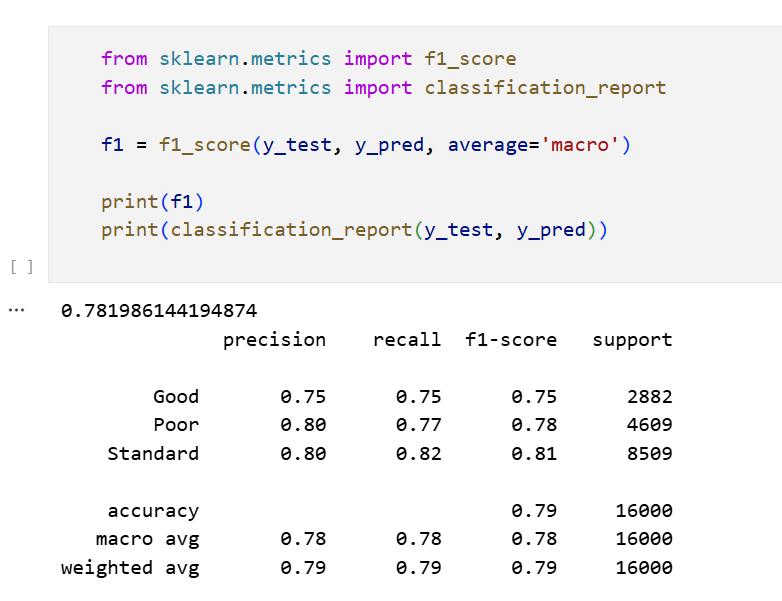

Save model

In [400]:
# import joblib
# from sklearn.pipeline import Pipeline

# pipeline = Pipeline([
#     ("selector", selector),
#     ("model", final_model)
# ])

# pipeline.fit(X_train, y_train)

# joblib.dump(pipeline, "credit_model.pkl")

Call

In [401]:
# pipeline = joblib.load("credit_model.pkl")
# y_pred = pipeline.predict(X_test)

Feature Selection

In [402]:
y_train_num = y_train.map({
    'Poor': 0,
    'Good': 1,
    'Standard': 2
})

In [403]:
y_test_num = y_test.map({
    'Poor': 0,
    'Good': 1,
    'Standard': 2
})

In [404]:
from xgboost import XGBClassifier

In [405]:
# train XGBoost
xgb = XGBClassifier(n_estimators=300, random_state=42)
xgb.fit(X_train, y_train_num)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [406]:
# feature importance
importance = pd.Series(
    xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# select top 15 features
top_features = importance.head(15).index

print("Top features:")
print(top_features)

Top features:
Index(['cat__Credit_Mix_Standard', 'cat__Credit_Mix_Good',
       'cat__Credit_Mix_Bad', 'num__Outstanding_Debt', 'num__Interest_Rate',
       'cat__Month_January', 'num__Num_Credit_Card', 'cat__Month_March',
       'cat__Month_February', 'num__Changed_Credit_Limit',
       'num__Delay_from_due_date',
       'cat__Type_of_Loan_Debt Consolidation Loan, and Student Loan',
       'num__Num_Bank_Accounts',
       'cat__Type_of_Loan_Student Loan, and Not Specified',
       'cat__Type_of_Loan_Not Specified, Mortgage Loan, and Debt Consolidation Loan'],
      dtype='object')


In [407]:
# Selected data
selected_idx = [list(feature_names).index(f) for f in top_features]

X_train_selected = X_train[:, selected_idx]
X_test_selected = X_test[:, selected_idx]

Fit Logistic and Naive Bayes

In [408]:
# train logistic model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial'
)

log_model.fit(X_train_selected, y_train)

# predict
y_pred_log = log_model.predict(X_test_selected)

In [409]:
# evaluate
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

f1 = f1_score(y_test, y_pred_log, average='macro')

print(f1)
print(classification_report(y_test, y_pred_log))

0.5974334339522108
              precision    recall  f1-score   support

        Good       0.50      0.80      0.61      2882
        Poor       0.63      0.41      0.50      4609
    Standard       0.69      0.68      0.68      8509

    accuracy                           0.62     16000
   macro avg       0.60      0.63      0.60     16000
weighted avg       0.64      0.62      0.62     16000



In [410]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

# convert sparse to dense
X_train_dense = X_train_selected.toarray()
X_test_dense = X_test_selected.toarray()

nb_model.fit(X_train_dense, y_train_num)

y_pred_nb = nb_model.predict(X_test_dense)

In [411]:
# evaluate

f1 = f1_score(y_test_num, y_pred_nb, average='macro')

print(f1)
print(classification_report(y_test_num, y_pred_nb))

0.6182824535825922
              precision    recall  f1-score   support

           0       0.60      0.53      0.57      4609
           1       0.49      0.84      0.62      2882
           2       0.74      0.61      0.67      8509

    accuracy                           0.63     16000
   macro avg       0.61      0.66      0.62     16000
weighted avg       0.66      0.63      0.63     16000



Called real test set from Clean_TestSet.ipynb

In [423]:
import import_ipynb
import Clean_TestSet

In [436]:
X_processed2 = Clean_TestSet.X
X_processed2

,Month,Name,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,August,Alistair Barrf,18.0,Lawyer,3062594,2706.161667,6,5,27,2,...,11.0,Bad,1562.91,30.077191,129.0,Yes,42.941090,77.314276,High_spent_Medium_value_payments,400.360800
1,March,Alistair Barrf,17.0,Lawyer,3062594,2706.161667,6,5,27,2,...,11.0,Bad,1562.91,38.285928,124.0,Yes,42.941090,109.056519,High_spent_Medium_value_payments,368.618558
2,January,Arunah,25.0,Mechanic,5231268,4250.390000,6,5,17,4,...,2.0,Standard,202.68,23.679534,365.0,NM,108.366467,261.210979,Low_spent_Medium_value_payments,335.461553
3,January,Shirboni,18.0,Media_Manager,11378139,9549.782500,1,4,1,0,...,1.0,Good,1030.20,37.998760,183.0,No,0.000000,397.241846,Low_spent_Medium_value_payments,837.736404
4,May,Shirboni,19.0,Media_Manager,11378139,9549.782500,1,4,1,0,...,1.0,Good,1030.20,32.035662,187.0,No,0.000000,758.083195,Low_spent_Small_value_payments,486.895055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,January,Poornimaf,36.0,Entrepreneur,2554626,2415.855000,8,7,14,5,...,5.0,Standard,758.44,37.418209,218.0,NM,101.328637,53.104599,High_spent_Medium_value_payments,337.152264
19996,June,Poornimaf,37.0,Entrepreneur,2554626,2415.855000,8,7,14,5,...,5.0,Standard,758.44,34.586599,218.0,Yes,101.328637,61.730748,High_spent_Small_value_payments,338.526114
19997,July,Shieldsb,19.0,Doctor,11763992,9727.326667,5,6,1,2,...,2.0,Good,338.30,23.631611,298.0,No,126.638453,1186.582604,Low_spent_Small_value_payments,337.531613
19998,February,Damouniq,29.0,Scientist,4139844,3749.870000,8,7,13,6,...,7.0,Standard,1701.88,27.117338,219.0,Yes,182.976650,132.363348,Low_spent_Small_value_payments,349.647003


In [437]:
X_processed2 = preprocess.transform(X_processed2)
X_processed2

<20000x16442 sparse matrix of type '<class 'numpy.float64'>'
	with 479155 stored elements in Compressed Sparse Row format>

In [441]:
X_processed2_new = selector.transform(X_processed2)

y_pred_real = final_model.predict(X_processed2_new)
print(y_pred_real)

['Poor' 'Poor' 'Standard' ... 'Standard' 'Standard' 'Standard']


In [444]:
print(len(y_pred_real))
pd.Series(y_pred_real).value_counts()

20000


Standard    10772
Poor         5668
Good         3560
dtype: int64

In [442]:
real_testset = pd.read_csv("test.csv")
real_testset['Credit_Score'] = y_pred_real
real_testset

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x2595b,CUS_0x3e03,June,Martinne Gellerj,23,504-67-6939,Developer,35971.49,NaN,5,...,_,132.82,39.548192,27 Years and 8 Months,Yes,54.481740,NaN,Low_spent_Small_value_payments,176.4421072,Poor
1,0xa2e2,CUS_0x3615,May,Samb,27,959-59-4160,Accountant,122425.8_,10001.150000,4,...,Standard,1252.3,39.469381,23 Years and 8 Months,Yes,148.188179,254.8090706,High_spent_Medium_value_payments,847.1177504,Poor
2,0x131cd,CUS_0x9122,April,Stanley Whitei,36,975-98-6988,Engineer,19773.56,1939.796667,4,...,_,1019.48,29.769062,23 Years and 1 Months,NM,10.358307,__10000__,Low_spent_Small_value_payments,294.0033384,Standard
3,0x1bced,CUS_0x3371,April,Maciejv,19,581-39-0550,Architect,61632.99,NaN,9,...,Bad,1634.98,31.566848,9 Years and 6 Months,Yes,311.564961,313.1820203,Low_spent_Medium_value_payments,140.8612683,Standard
4,0x1ee87,CUS_0xecc,June,Papadimase,25,248-56-1152,Lawyer,9413.305,1072.442083,8,...,Standard,1746.62,35.225618,NaN,Yes,32.742096,40.03202937,Low_spent_Medium_value_payments,314.4700825,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0x3ab7,CUS_0x36f9,February,Lucy Hornbyr,46,992-38-5349,Developer,82065.16,6771.763333,5,...,Good,106.83,35.131041,23 Years and 0 Months,No,180.340607,439.8401794,High_spent_Small_value_payments,316.9955472,Standard
19996,0x15798,CUS_0x70a3,July,Islan,20,291-89-8959,Accountant,14920.97,1424.414167,6,...,Standard,1288.58,33.572279,13 Years and 5 Months,Yes,19.909512,110.0842395,Low_spent_Small_value_payments,302.4476647,Standard
19997,0x1d81e,CUS_0x1cf3,May,Henryc,38,229-46-4057,Manager,66858.27,5770.522500,3,...,Standard,601.58,37.982933,28 Years and 1 Months,NM,175.015182,364.7070519,Low_spent_Medium_value_payments,317.3300163,Standard
19998,0x1b0a,CUS_0x2c0d,May,ernieh,55_,784-23-6447,Doctor,19403.405_,1904.950417,1,...,_,339.11,36.826610,16 Years and 8 Months,No,39.214914,169.8581974,Low_spent_Large_value_payments,251.4219299,Standard


In [ ]:
# real_testset.to_csv("prediction.csv", header=True, index=False)